# MSE803: Data Analytics - Assessment 1 Charts

**Dataset:** Avon River Water Quality & Fish Population Data (Oct-Dec 2023)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\Data_Set_Assignmnet_1-V0.1_20426.xlsx', header=1)
df.columns = ['Site','Date','Temp','pH','DO','_','Site2','Date2','Species','Count','AvgSize']
df = df[['Site','Date','Temp','pH','DO','Species','Count','AvgSize']].copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df_clean = df.dropna(subset=['Temp','DO','Count'])
colors = {'AV-1': '#2196F3', 'AV-2': '#4CAF50', 'AV-3': '#F44336'}
print(f'Dataset loaded: {len(df_clean)} records')
df_clean.head()

Dataset loaded: 71 records


,Site,Date,Temp,pH,DO,Species,Count,AvgSize,Month
0,AV-1,2023-11-06,13.5,7.88,7.9,Brown Trout,12,18.3,11
1,AV-2,2023-11-02,16.8,7.33,8.2,Shortfin Eel,7,42.1,11
2,AV-3,2023-10-21,15.1,7.60,7.5,Inanga,25,7.4,10
3,AV-1,2023-11-01,14.0,7.05,9.0,Longfin Eel,6,38.9,11
4,AV-2,2023-10-14,15.3,7.64,6.9,Brown Trout,9,17.0,10


## Figure 1: Water Temperature Over Time by Site

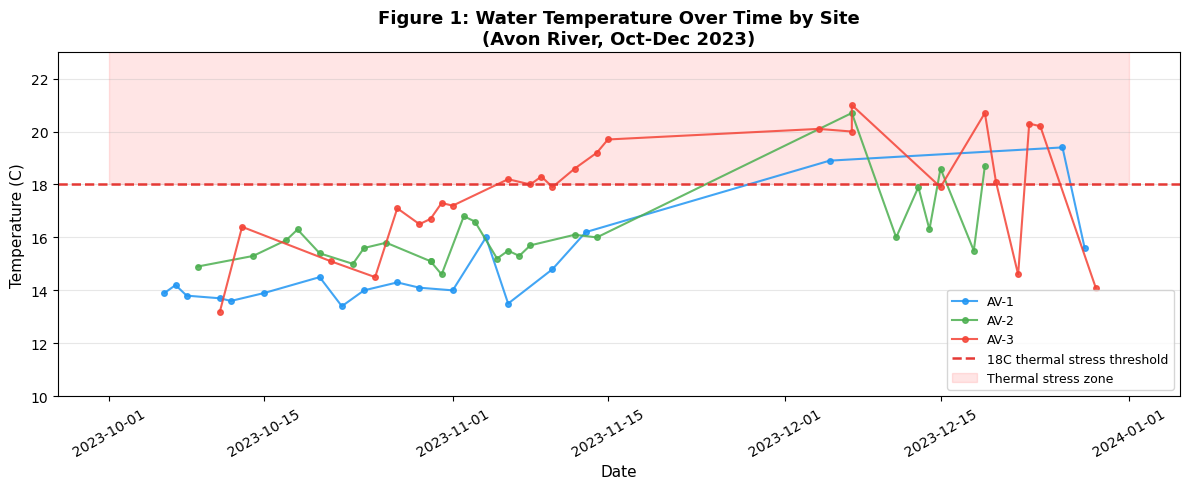

Figure 1 saved.


In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
for site in ['AV-1', 'AV-2', 'AV-3']:
    site_data = df_clean[df_clean['Site'] == site].sort_values('Date')
    ax.plot(site_data['Date'], site_data['Temp'], marker='o', markersize=4,
            linewidth=1.5, color=colors[site], label=site, alpha=0.85)
ax.axhline(y=18, color='#E53935', linestyle='--', linewidth=1.8, label='18C thermal stress threshold')
ax.fill_between(pd.date_range('2023-10-01', '2024-01-01'), 18, 25, alpha=0.10, color='red', label='Thermal stress zone')
ax.set_title('Figure 1: Water Temperature Over Time by Site\n(Avon River, Oct-Dec 2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Temperature (C)', fontsize=11)
ax.set_ylim(10, 23)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\chart1_temp_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Figure 2: Dissolved Oxygen Levels Over Time by Site

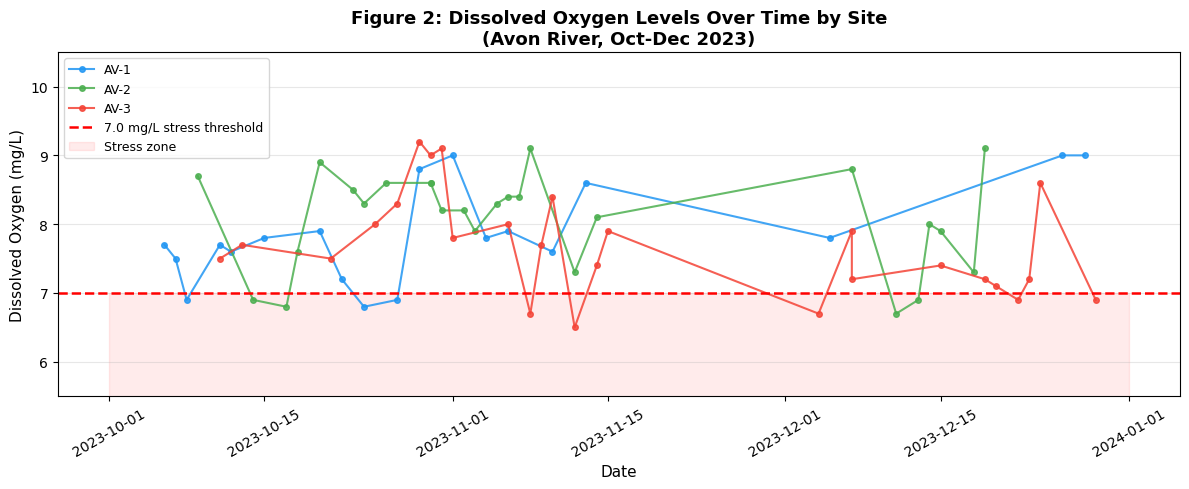

Figure 2 saved.


In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
for site in ['AV-1', 'AV-2', 'AV-3']:
    site_data = df_clean[df_clean['Site'] == site].sort_values('Date')
    ax.plot(site_data['Date'], site_data['DO'], marker='o', markersize=4,
            linewidth=1.5, color=colors[site], label=site, alpha=0.85)
ax.axhline(y=7.0, color='red', linestyle='--', linewidth=1.8, label='7.0 mg/L stress threshold')
ax.fill_between(pd.date_range('2023-10-01', '2024-01-01'), 0, 7.0, alpha=0.08, color='red', label='Stress zone')
ax.set_title('Figure 2: Dissolved Oxygen Levels Over Time by Site\n(Avon River, Oct-Dec 2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Dissolved Oxygen (mg/L)', fontsize=11)
ax.set_ylim(5.5, 10.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\chart2_do_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Figure 4: Mean Monthly Temperature and Fish Count by Site

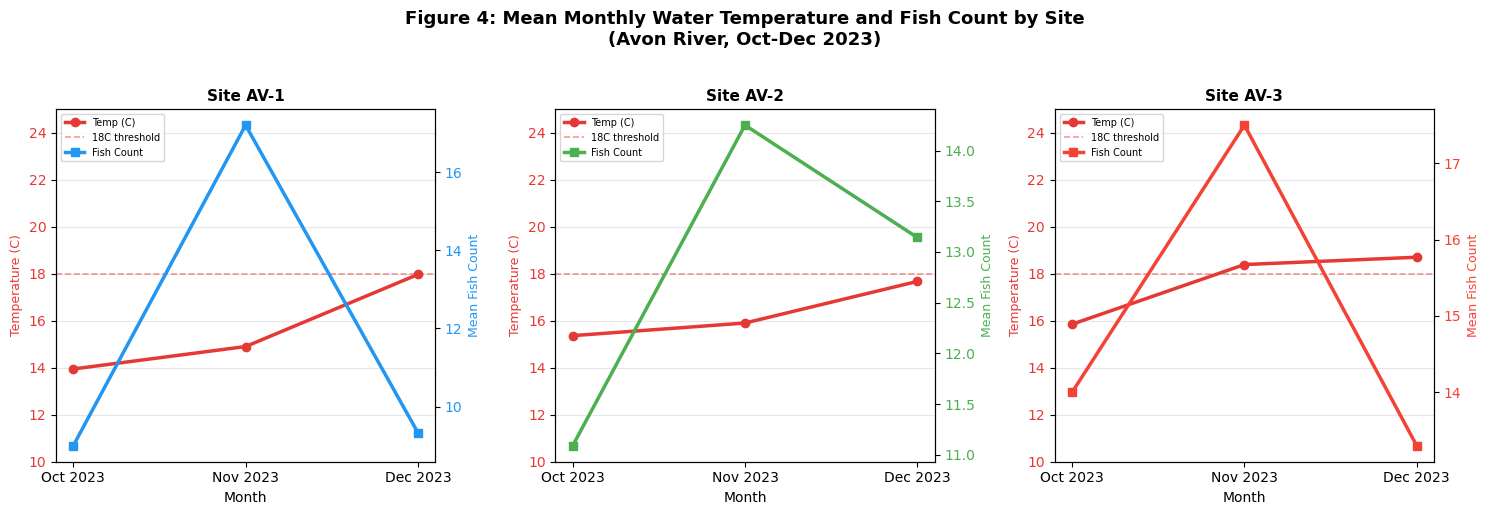

Figure 4 saved.


In [25]:
month_labels = {10: 'Oct 2023', 11: 'Nov 2023', 12: 'Dec 2023'}
monthly = df_clean.groupby(['Site', 'Month']).agg({'Temp': 'mean', 'Count': 'mean'}).reset_index()
monthly['MonthLabel'] = monthly['Month'].map(month_labels)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 4: Mean Monthly Water Temperature and Fish Count by Site\n(Avon River, Oct-Dec 2023)', fontsize=13, fontweight='bold', y=1.02)
for i, site in enumerate(['AV-1', 'AV-2', 'AV-3']):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    site_data = monthly[monthly['Site'] == site].sort_values('Month')
    ax1.plot(site_data['MonthLabel'], site_data['Temp'], color='#E53935', marker='o', linewidth=2.5, label='Temp (C)', zorder=3)
    ax1.axhline(y=18, color='#E53935', linestyle='--', alpha=0.5, linewidth=1.2, label='18C threshold')
    ax2.plot(site_data['MonthLabel'], site_data['Count'], color=colors[site], marker='s', linewidth=2.5, label='Fish Count', zorder=3)
    ax1.set_xlabel('Month', fontsize=10)
    ax1.set_ylabel('Temperature (C)', color='#E53935', fontsize=9)
    ax2.set_ylabel('Mean Fish Count', color=colors[site], fontsize=9)
    ax1.set_title(f'Site {site}', fontsize=11, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#E53935')
    ax2.tick_params(axis='y', labelcolor=colors[site])
    ax1.set_ylim(10, 25)
    ax1.grid(axis='y', alpha=0.3)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\chart4_temp_count_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Figure 5: Fish Species Composition per Site

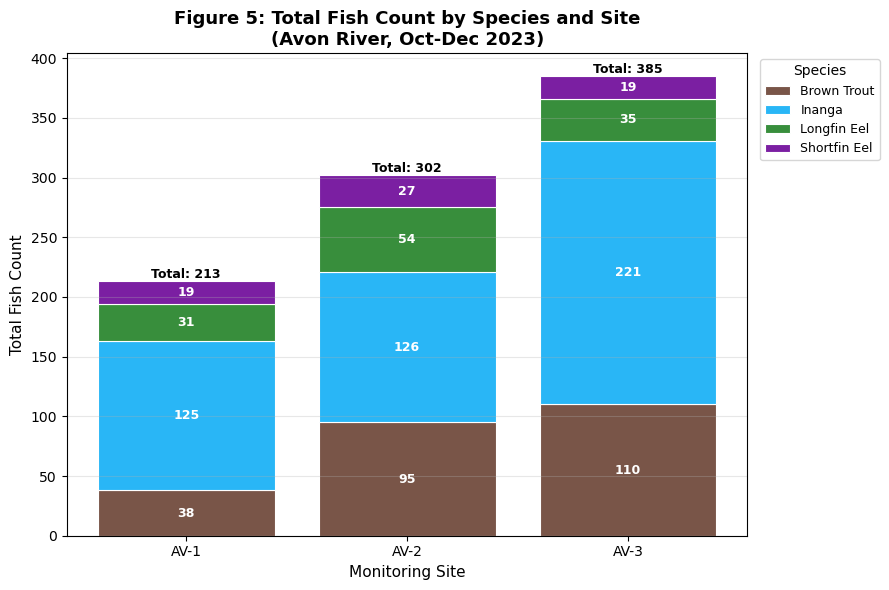

Figure 5 saved.


In [26]:
species_data = df_clean.groupby(['Site', 'Species'])['Count'].sum().unstack(fill_value=0)
sp_colors = {'Brown Trout': '#795548', 'Inanga': '#29B6F6', 'Longfin Eel': '#388E3C', 'Shortfin Eel': '#7B1FA2'}
fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(3)
sites = species_data.index.tolist()
for sp in species_data.columns:
    vals = species_data[sp].values
    ax.bar(sites, vals, bottom=bottom, label=sp, color=sp_colors.get(sp, 'gray'), edgecolor='white', linewidth=0.8)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(j, b + v / 2, str(int(v)), ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += vals
totals = species_data.sum(axis=1)
for j, (site, total) in enumerate(totals.items()):
    ax.text(j, total + 3, f'Total: {int(total)}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Figure 5: Total Fish Count by Species and Site\n(Avon River, Oct-Dec 2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Monitoring Site', fontsize=11)
ax.set_ylabel('Total Fish Count', fontsize=11)
ax.legend(title='Species', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\chart5_species_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## Figure 3: Pearson Correlation Heatmap

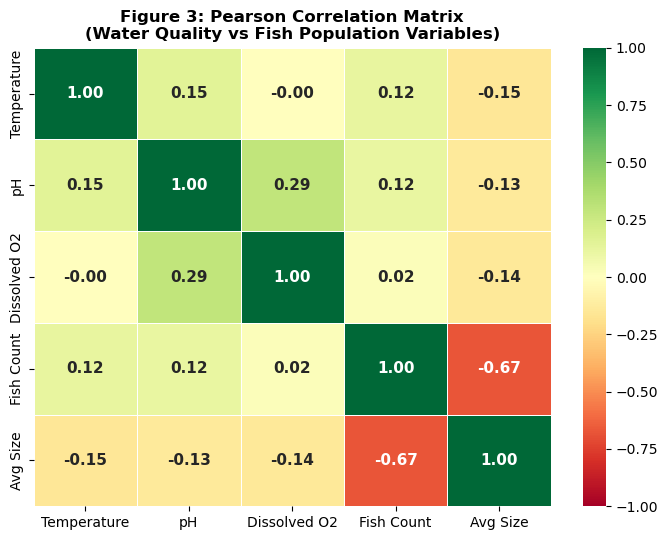

Figure 3 saved.


In [27]:
corr_df = df_clean[['Temp', 'pH', 'DO', 'Count', 'AvgSize']].dropna()
corr_df.columns = ['Temperature', 'pH', 'Dissolved O2', 'Fish Count', 'Avg Size']
corr_matrix = corr_df.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Figure 3: Pearson Correlation Matrix\n(Water Quality vs Fish Population Variables)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Yoobee College\DA\Activities\MSE-803-Data-Analytics\week 10\chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Statistical Summary

In [28]:
print('=== Site Summary Statistics ===')
print(df_clean.groupby('Site').agg(
    Mean_Temp=('Temp', 'mean'),
    Max_Temp=('Temp', 'max'),
    Mean_DO=('DO', 'mean'),
    Min_DO=('DO', 'min'),
    Mean_Count=('Count', 'mean')
).round(2))
print('\n=== Pearson Correlations by Site ===')
for site in ['AV-1', 'AV-2', 'AV-3']:
    s = df_clean[df_clean['Site'] == site]
    r_tc, p_tc = stats.pearsonr(s['Temp'], s['Count'])
    r_dc, p_dc = stats.pearsonr(s['DO'], s['Count'])
    print(f'{site} | Temp vs Count: r={r_tc:.3f} p={p_tc:.3f} | DO vs Count: r={r_dc:.3f} p={p_dc:.3f}')
print('\n=== Low DO Events (< 7.0 mg/L) ===')
low_do = df_clean[df_clean['DO'] < 7.0]
print(low_do[['Site', 'Date', 'Temp', 'DO', 'Species', 'Count']].to_string(index=False))

=== Site Summary Statistics ===
      Mean_Temp  Max_Temp  Mean_DO  Min_DO  Mean_Count
Site                                                  
AV-1      14.83      19.4     7.87     6.8       11.21
AV-2      16.15      20.7     8.08     6.7       12.62
AV-3      17.73      21.0     7.68     6.5       14.81

=== Pearson Correlations by Site ===
AV-1 | Temp vs Count: r=0.234 p=0.335 | DO vs Count: r=0.117 p=0.634
AV-2 | Temp vs Count: r=-0.149 p=0.467 | DO vs Count: r=0.194 p=0.343
AV-3 | Temp vs Count: r=-0.011 p=0.959 | DO vs Count: r=-0.096 p=0.641

=== Low DO Events (< 7.0 mg/L) ===
Site       Date  Temp  DO      Species  Count
AV-2 2023-10-14  15.3 6.9  Brown Trout      9
AV-3 2023-11-12  18.6 6.5       Inanga     30
AV-2 2023-10-17  15.9 6.8  Longfin Eel      3
AV-1 2023-10-27  14.3 6.9  Longfin Eel      6
AV-3 2023-11-08  18.0 6.7 Shortfin Eel      8
AV-1 2023-10-08  13.8 6.9 Shortfin Eel      3
AV-1 2023-10-24  14.0 6.8  Longfin Eel      5
AV-2 2023-12-13  17.9 6.9       Inanga   